# The variational quantum eigensolver

This notebook accompanies Chapter 20.  It is the practical half of the pair
begun in `quantumfourier.ipynb`: where phase estimation solved the eigenvalue
problem exactly on a machine that does not exist, the variational quantum
eigensolver solves it approximately on machines that do.

Everything here uses the same two example Hamiltonians and the same four
many-body models as Chapter 19, so that the two algorithms can be compared
without also changing the problem.

The topics, in order:

1. **Measurement** — the only operation hardware offers, and what has to be
   done to every observable in consequence.
2. **Why single-qubit readout fails** — a theorem, a counterexample, and a VQE
   run that converges confidently to the wrong answer.
3. **The parameter-shift rule** — exact gradients from two extra evaluations,
   and what happens when its hypothesis is violated.
4. **Applications** — the one- and two-qubit Hamiltonians, both Lipkin
   encodings, and the models of Chapter 4.
5. **QPE against VQE** — the comparison, with numbers.

In [1]:
import sys
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import math
import numpy as np
import matplotlib.pyplot as plt

import vqe
from qpe import pauli_terms, commuting_groups, heisenberg_qubit, hubbard_qubit

np.set_printoptions(precision=6, suppress=True)

## 1. Measurement

A quantum computer measures in the computational basis, the eigenbasis of
$Z$, and does nothing else.  Every other Pauli has to be rotated into it
first:

| observable | circuit before readout | why |
|---|---|---|
| $Z$ | nothing | already diagonal |
| $X$ | $H$ | $HZH = X$ |
| $Y$ | $S^\dagger$ then $H$ | $HS^\dagger Y S H = Z$ |

Three circuits, applied qubit by qubit, are enough for every Pauli string and
hence for every Hamiltonian.  The check below compares the value obtained by
rotating and averaging parities with the matrix element.

In [2]:
rng = np.random.default_rng(2024)
state = rng.normal(size=4) + 1j * rng.normal(size=4)
state /= np.linalg.norm(state)

table = {"I": vqe.I2, "X": vqe.X, "Y": vqe.Y, "Z": vqe.Z}
print(f"{'string':>8s} {'rotation + readout':>22s} {'<psi|P|psi>':>16s} {'difference':>12s}")
for label in ("ZI", "XI", "YI", "XX", "YY", "ZZ", "XZ", "YX"):
    matrix = np.kron(table[label[0]], table[label[1]])
    direct = float(np.real(state.conj() @ matrix @ state))
    rotated = vqe.expectation_exact(state, label)
    print(f"{label:>8s} {rotated:22.12f} {direct:16.12f} {abs(rotated-direct):12.2e}")

  string     rotation + readout      <psi|P|psi>   difference
      ZI         0.271768423177   0.271768423177     0.00e+00
      XI        -0.353387605906  -0.353387605906     0.00e+00
      YI         0.755358124253   0.755358124253     2.22e-16
      XX         0.051381632678   0.051381632678     1.32e-16
      YY         0.814800305114   0.814800305114     4.44e-16
      ZZ        -0.061650724655  -0.061650724655     8.33e-17
      XZ         0.344514962268   0.344514962268     2.22e-16
      YX         0.112841856865   0.112841856865     1.39e-16


### Shot noise

Each shot returns a single bit string.  The estimator of $\langle P\rangle$ is
the average parity over the shots, unbiased with variance
$(1-\langle P\rangle^2)/N$, so the error falls as $1/\sqrt{N}$ — and nothing
can be done about it.  An extra decimal digit costs a hundred times more
measurements, and this single fact governs the economics of the whole
algorithm.

In [3]:
hamiltonian = vqe.two_qubit_hamiltonian()
terms = pauli_terms(hamiltonian)
trial = vqe.hardware_efficient(rng.uniform(0, 2*math.pi, 8), 2, 2)

shot_list = [10, 100, 1000, 10000]
exact, rows = vqe.shot_noise_scaling(trial, terms, shot_list, repeats=200)
print(f"exact energy of this state {exact:.6f}\n")
print(f"{'shots':>8s} {'std. error':>12s} {'x sqrt(shots)':>15s} {'bias':>12s}")
for shots, spread, bias in rows:
    print(f"{shots:8d} {spread:12.5f} {spread*math.sqrt(shots):15.4f} {bias:12.5f}")

exact energy of this state 6.462065

   shots   std. error   x sqrt(shots)         bias
      10      0.98912          3.1279     -0.00782
     100      0.28090          2.8090     -0.02337
    1000      0.08512          2.6918      0.00228
   10000      0.02989          2.9891      0.00002


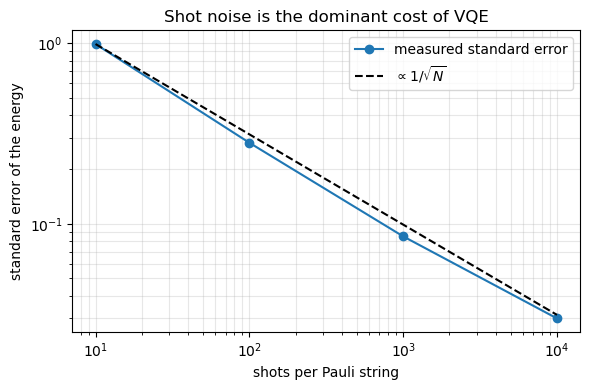

In [4]:
shots = np.array([r[0] for r in rows], dtype=float)
errors = np.array([r[1] for r in rows])

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(shots, errors, "o-", label="measured standard error")
ax.loglog(shots, errors[0]*np.sqrt(shots[0]/shots), "k--", label=r"$\propto 1/\sqrt{N}$")
ax.set_xlabel("shots per Pauli string")
ax.set_ylabel("standard error of the energy")
ax.set_title("Shot noise is the dominant cost of VQE")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Why single-qubit readout is not enough

It is tempting to measure each qubit separately and multiply,
$\langle Z_1Z_2\rangle \approx \langle Z_1\rangle\langle Z_2\rangle$.
This is false, and the way in which it is false is quiet rather than loud.

The single-qubit statistics of a state are precisely the content of its
reduced density matrices, and the reduced density matrices are obtained by
tracing out the other qubit — an operation whose whole purpose is to discard
correlations.  Two states with identical marginals and opposite correlator:

In [5]:
print(f"{'state':>26s} {'<Z_1>':>9s} {'<Z_2>':>9s} {'<Z_1 Z_2>':>11s}")
for name, values in vqe.marginal_counterexample().items():
    print(f"{name:>26s} {values['z1']:9.4f} {values['z2']:9.4f} {values['zz']:11.4f}")

                     state     <Z_1>     <Z_2>   <Z_1 Z_2>
     (|00> + |11>)/sqrt(2)    0.0000    0.0000      1.0000
     (|01> + |10>)/sqrt(2)    0.0000    0.0000     -1.0000


### What it does to a VQE landscape

Take $H = Z_1Z_2$ with the ansatz
$|\psi(\theta)\rangle = \cos\theta|00\rangle + \sin\theta|11\rangle$.  Both
basis states have even parity, so **every** member of the family has
$\langle Z_1Z_2\rangle = 1$ and the true landscape is flat.  The marginal
reconstruction gives $\cos^2 2\theta$ instead: an oscillatory landscape with
spurious minima where it reports $0$.

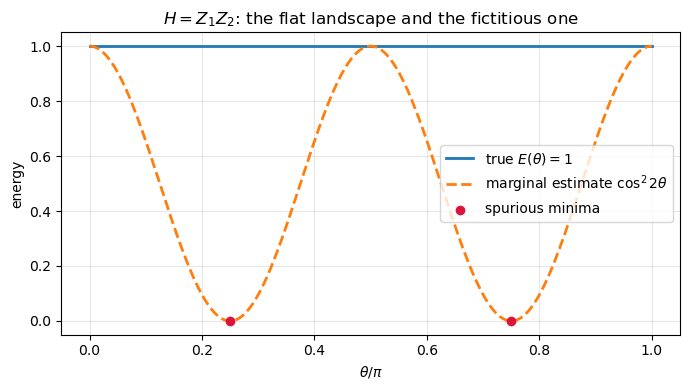

In [6]:
thetas, exact_land, naive_land = vqe.vqe_failure_landscape()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thetas/math.pi, exact_land, lw=2, label=r"true $E(\theta) = 1$")
ax.plot(thetas/math.pi, naive_land, lw=2, ls="--",
        label=r"marginal estimate $\cos^2 2\theta$")
ax.scatter([0.25, 0.75], [0, 0], color="crimson", zorder=5,
           label="spurious minima")
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel("energy")
ax.set_title(r"$H = Z_1 Z_2$: the flat landscape and the fictitious one")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The same failure inside a real VQE run.  Note what the last two rows show:
the number the optimiser reports is not the energy of the state it actually
prepared, and the variational guarantee is gone with it.  A quantity that is
not $\langle\psi|H|\psi\rangle$ for any $\psi$ is under no obligation to lie
above $E_0$ — so it can equally well come out too low, and then nothing at all
identifies it as wrong.

In [7]:
exact_spectrum = np.linalg.eigvalsh(hamiltonian)
honest = vqe.vqe(hamiltonian, 2, layers=2, iterations=300, seed=3)
broken = vqe.vqe(hamiltonian, 2, layers=2, iterations=300, seed=3, marginal=True)

print(f"exact ground state           {exact_spectrum[0]:11.6f}")
print(f"VQE, joint readout           {honest['energy']:11.6f}")
print(f"VQE, marginal reconstruction {broken['energy']:11.6f}   <- reported")
print(f"true energy of that state    {broken['true_energy']:11.6f}   <- prepared")

exact ground state             -0.531129
VQE, joint readout             -0.531129
VQE, marginal reconstruction    0.000024   <- reported
true energy of that state       0.000080   <- prepared


The shortcut is not even cheaper.  A single shot of a two-qubit circuit
returns **both** bits, so the same data that give $\langle Z_1\rangle$ and
$\langle Z_2\rangle$ give $\langle Z_1Z_2\rangle$ at no extra cost.  The rule:

> **measure all qubits, form the parity of each string, then average.**

Averaging first and multiplying afterwards is the error, and the order of the
two operations is the whole of the difference.

## 3. The parameter-shift rule

If a parameter enters as $e^{-i\theta P/2}$ with $P$ a Pauli string, then
$P/2$ has eigenvalues $\pm 1/2$ and the energy is a trigonometric polynomial
of frequency one,

$$E(\theta) = A + B\cos\theta + C\sin\theta.$$

Three unknowns, so three evaluations determine the function and two determine
its derivative.  First the functional form — fit $A$, $B$, $C$ at three points
and predict everywhere else:

In [8]:
print(f"largest prediction error of the three-point fit: "
      f"{vqe.check_trigonometric_structure():.2e}")

checks = vqe.check_parameter_shift()
print(f"shift rule vs. finite difference: {checks['max_difference']:.2e}")
print(f"(gradient norm {checks['gradient_norm']:.4f})")

largest prediction error of the three-point fit: 3.55e-15
shift rule vs. finite difference: 2.40e-10
(gradient norm 3.3573)


This is **not** a finite difference with a clever step size.  The shift is
$\pi/2$ — enormous — and the result is exact.  That matters on hardware, where
a finite difference with a small step subtracts two noisy numbers that are
nearly equal.

The hypothesis is that the generator has two eigenvalues.  For
$G = (Z_1+Z_2)/2$, whose eigenvalues are $-1, 0, +1$, the energy has two
frequencies and the two-point rule does not merely lose accuracy — it returns
**zero**, and an optimiser using it would conclude it had reached a stationary
point and stop.

In [9]:
fails = vqe.shift_rule_fails()
print(f"generator spectrum   {fails['spectrum']}")
print(f"exact derivative     {fails['exact']:+.6f}")
print(f"two-point rule       {fails['two_point']:+.6f}   error {fails['two_point_error']:.2e}")
print(f"four-term rule       {fails['four_point']:+.6f}   error {fails['four_point_error']:.2e}")

generator spectrum   [-1.  0.  1.]
exact derivative     -0.970535
two-point rule       +0.000000   error 9.71e-01
four-term rule       -0.970535   error 5.32e-10


## 4. Applications

### The one-qubit Hamiltonian

Two angles reach every point on the Bloch sphere, so for a one-qubit
Hamiltonian the ansatz is **exact**: the variational minimum is the true
ground state and the only error is the optimiser's.  This is the last case in
which anything of the kind is true.

In [10]:
print(f"{'lambda':>8s} {'exact E_0':>12s} {'VQE':>12s} {'error':>11s}")
for lam in (0.0, 0.5, 1.0):
    h1 = vqe.one_qubit_hamiltonian(lam=lam)
    exact_1 = vqe.one_qubit_exact(lam=lam)[0]
    out = vqe.vqe(h1, 1, layers=1, iterations=300, learning_rate=0.2, seed=1)
    print(f"{lam:8.2f} {exact_1:12.6f} {out['energy']:12.6f} "
          f"{abs(out['energy']-exact_1):11.2e}")

  lambda    exact E_0          VQE       error
    0.00     0.000000     0.000000    1.28e-30
    0.50     1.490098     1.490140    4.20e-05
    1.00     0.980196     0.980215    1.89e-05


### The two-qubit Hamiltonian

The ground state is a superposition of $|00\rangle$ and $|11\rangle$ — the
$X\otimes X$ term couples exactly those — so it is entangled, and a single
CNOT suffices to reach it.  One layer is enough; extra layers add parameters
the optimiser must navigate around without adding anything reachable.

Every value lies **above** the exact one, as the variational principle
requires.  Contrast Table 19.5, where phase estimation returned $-0.583333$ at
$m=4$: a number *below* the true ground-state energy, which no variational
method could produce and which is a perfectly normal QPE result.

In [11]:
history = {}
print(f"{'layers':>8s} {'parameters':>12s} {'VQE':>12s} {'error':>11s}")
for layers in (1, 2, 3):
    out = vqe.vqe(hamiltonian, 2, layers=layers, iterations=400, seed=3)
    history[layers] = out["history"]
    print(f"{layers:8d} {vqe.n_parameters(2, layers):12d} {out['energy']:12.6f} "
          f"{abs(out['energy']-exact_spectrum[0]):11.2e}")
print(f"\nexact ground state {exact_spectrum[0]:.6f}")

  layers   parameters          VQE       error


       1            4    -0.531129    2.22e-16


       2            8    -0.531129    8.95e-13


       3           12    -0.531129    2.22e-16

exact ground state -0.531129


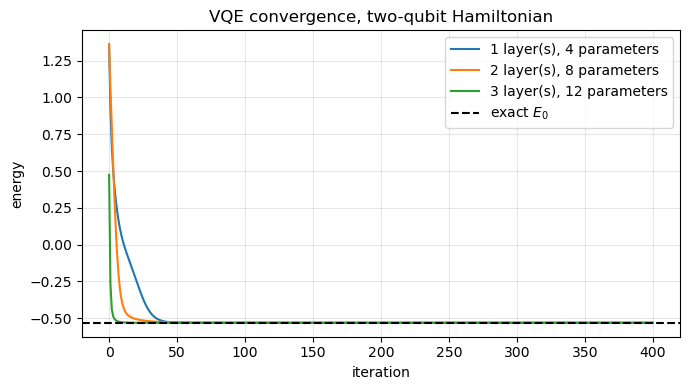

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for layers, curve in history.items():
    ax.plot(curve, label=f"{layers} layer(s), {vqe.n_parameters(2, layers)} parameters")
ax.axhline(exact_spectrum[0], color="k", ls="--", label="exact $E_0$")
ax.set_xlabel("iteration")
ax.set_ylabel("energy")
ax.set_title("VQE convergence, two-qubit Hamiltonian")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The Lipkin model: two encodings

Fixing the maximal quasispin $j = N/2$ and using
$J_+J_- + J_-J_+ = 2(J^2 - J_z^2)$ reduces the Lipkin Hamiltonian to a matrix
of dimension $N+1$.  Two ways to put that on qubits:

- the **direct** mapping, one qubit per particle, exponentially wasteful in
  qubits but with every Pauli string of weight two and no Jordan-Wigner tails
  (the two Lipkin levels are degenerate, so the tails cancel);
- a **compressed** mapping into $\lceil\log_2(N+1)\rceil$ qubits, optimal in
  qubits but with longer strings and unphysical register states that have to
  be policed with a penalty term.

Neither is uniformly better.  The check that they describe the same physics is
that the maximal-spin block of the direct Hamiltonian reproduces the quasispin
spectrum exactly.

In [13]:
for N in (4, 6):
    quasispin = vqe.lipkin_quasispin(N, eps=1.0, V=1.0, W=0.0)
    direct = vqe.lipkin_direct_qubits(N, eps=1.0, V=1.0, W=0.0)
    block = vqe.lipkin_symmetric_block(N, eps=1.0, V=1.0, W=0.0)
    labels = [l for l in pauli_terms(direct) if l.count("I") != len(l)]
    sq = np.linalg.eigvalsh(quasispin)
    sd = np.linalg.eigvalsh(direct)
    print(f"N = {N}:")
    print(f"   quasispin block: dimension {len(quasispin)}, E_0 = {sq[0]:+.6f}")
    print(f"   direct mapping:  {N} qubits, {len(labels)} strings, max weight 2")
    print(f"   E_0 of the {1<<N}-dimensional qubit Hamiltonian: {sd[0]:+.6f}")
    print(f"   symmetric block vs. quasispin form: "
          f"{np.abs(np.linalg.eigvalsh(block) - sq).max():.2e}")
    print(f"   a compressed encoding would need "
          f"ceil(log2({N+1})) = {int(math.ceil(math.log2(N+1)))} qubits\n")

N = 4:
   quasispin block: dimension 5, E_0 = -4.000000
   direct mapping:  4 qubits, 16 strings, max weight 2
   E_0 of the 16-dimensional qubit Hamiltonian: -4.000000
   symmetric block vs. quasispin form: 0.00e+00
   a compressed encoding would need ceil(log2(5)) = 3 qubits



N = 6:
   quasispin block: dimension 7, E_0 = -8.321118
   direct mapping:  6 qubits, 36 strings, max weight 2
   E_0 of the 64-dimensional qubit Hamiltonian: -8.321118
   symmetric block vs. quasispin form: 0.00e+00
   a compressed encoding would need ceil(log2(7)) = 3 qubits



### The models of Chapter 4

The same four systems Chapter 19 fed to phase estimation.  The
hardware-efficient ansatz is used throughout, deliberately: it carries no
information about any of these Hamiltonians, so where it falls short the fault
is the ansatz's and not the algorithm's.

Watch the Lipkin row.  Its exact ground state lies in the fully symmetric
subspace, since the Hamiltonian is permutation-invariant, but the CNOT ladder
singles out a direction along the chain and so breaks that symmetry.  The
optimiser gets close and stops — two orders of magnitude worse than the other
three rows, on the *smallest* Hilbert space of the four.

**The quality of a VQE result is a property of the ansatz, not of the
algorithm.**  The optimiser converged in every row, and the convergence
carries no information about whether the answer is right.

In [14]:
from jordanwigner import pairing_pair_qubits

models = [("Lipkin, N = 4", vqe.lipkin_direct_qubits(4, 1.0, 1.0), 4),
          ("pairing, 3 levels", pairing_pair_qubits(3, g=1.0), 3),
          ("Heisenberg, 3 sites", heisenberg_qubit(3, J=1.0), 3),
          ("Hubbard, 2 sites", hubbard_qubit(2, t=1.0, U=2.0), 4)]

print(f"{'model':>20s} {'qubits':>7s} {'layers':>7s} {'exact':>11s} "
      f"{'VQE':>11s} {'error':>10s} {'groups':>7s}")
for name, ham, nq in models:
    exact_e = float(np.linalg.eigvalsh(ham)[0])
    best = None
    for layers in (2, 3, 4):
        for seed in (7, 17, 27, 37):
            out = vqe.vqe(ham, nq, layers=layers, iterations=300,
                          learning_rate=0.15, seed=seed)
            if best is None or out["energy"] < best[0]:
                best = (out["energy"], layers)
    labels = [l for l in pauli_terms(ham) if l.count("I") != len(l)]
    print(f"{name:>20s} {nq:7d} {best[1]:7d} {exact_e:11.5f} {best[0]:11.5f} "
          f"{abs(best[0]-exact_e):10.2e} {len(commuting_groups(labels)):7d}")

               model  qubits  layers       exact         VQE      error  groups


       Lipkin, N = 4       4       3    -4.00000    -3.99379   6.21e-03       4


   pairing, 3 levels       3       4    -0.70530    -0.70527   3.26e-05       4


 Heisenberg, 3 sites       3       4    -0.75000    -0.75000   1.11e-16       4


    Hubbard, 2 sites       4       2    -1.23607    -1.23607   2.17e-08       2


## 5. Phase estimation and VQE

The last column above is the measurement cost: with $G$ commuting groups and
$S$ shots each, one energy evaluation costs $GS$ measurements and one
parameter-shift gradient costs $2PGS$ for $P$ parameters.  For the four-qubit,
four-layer ansatz that is $256S$ measurements per optimisation step, and a few
hundred steps at $S = 10^4$ comes to $10^9$ measurements — for a problem a
laptop diagonalises instantly.

|  | phase estimation | VQE |
|---|---|---|
| qubits | $n + m$, $m = O(\log 1/\epsilon)$ | $n$ |
| circuit depth | $O(\Lambda t/\epsilon)$, coherent | $O(nL)$, shallow |
| repetitions | $O(1)$ per bit | $O(\Lambda^2/\epsilon^2)$ per energy |
| error scaling | $\epsilon \sim 2^{-m}$ | $\epsilon \sim 1/\sqrt{N}$ |
| input needed | a state with good overlap | an expressive ansatz |
| output | an eigenvalue, either side of $E_0$ | an upper bound on $E_0$ |
| noise | fatal | degrades the bound |
| bottleneck | **depth** | **measurements** |
| fails | loudly | quietly |

The two error scalings are the crux.  QPE buys a bit of precision per control
qubit — exponential accuracy in the register size — while VQE buys it at
$\epsilon \sim N^{-1/2}$.  Asymptotically this is no contest.  The crossover
is not asymptotic: at $\epsilon = 10^{-3}$ with $\Lambda \sim 10^3$, VQE needs
of order $10^{12}$ measurements, out of reach but not absurd, while QPE needs
a coherent circuit of $10^6$–$10^9$ gates, which requires error correction and
therefore a machine that does not exist.

VQE is not better.  It is runnable, and it is runnable because its errors are
of a kind that can be averaged away rather than a kind that destroys the
computation.

The most plausible use of the two is together: the shallow circuit prepares
the state, the deep one measures it and, in doing so, projects onto the
eigenstate.  Neither algorithm has yet produced a many-body result beyond
classical reach, and the obstacles are different in kind — hardware for phase
estimation, mathematics for VQE.